#### 2.3.1.  Начальная установка


In [1]:
import os
import random
import csv
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torchvision

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")
RUNS_PATH = os.path.join(ARTIFACTS_DIR, "runs.csv")

os.makedirs(FIGURES_DIR, exist_ok=True)


Torch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu
CUDA available: False
Device: cpu


#### 2.3.2. Данные и DataLoader
1) Загрузить выбранный датасет через `torchvision.datasets.*`.  
2) Определить `transform` (минимум `ToTensor()`, нормализация – по желанию).  


In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset_full = datasets.EMNIST(
    root="./data",
    split="balanced",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.EMNIST(
    root="./data",
    split="balanced",
    train=False,
    download=True,
    transform=transform
)


3) Сделать разбиение `train/val` из train-части с фиксированным seed.

In [3]:
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)


print("Размер train:", len(train_dataset))
print("Размер val:", len(val_dataset))
print("Размер test:", len(test_dataset))

Размер train: 90240
Размер val: 22560
Размер test: 18800


4) Создать `DataLoader` для train/val/test.

In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

5) Показать sanity-check: размеры батча, shapes (`x.shape`, `y.shape`), диапазоны значений.

In [5]:
x, y = next(iter(train_loader))

print("x shape:", x.shape)
print("y shape:", y.shape)

print("min pixel:", x.min().item())
print("max pixel:", x.max().item())

x shape: torch.Size([64, 1, 28, 28])
y shape: torch.Size([64])
min pixel: 0.0
max pixel: 1.0


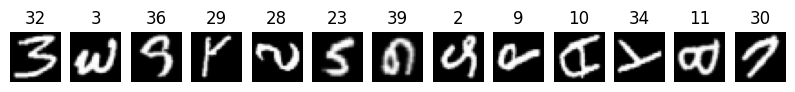

In [6]:
fig, axes = plt.subplots(1, 13, figsize=(10,3))

for i in range(13):
    axes[i].imshow(x[i].squeeze(), cmap="gray")
    axes[i].set_title(int(y[i]))
    axes[i].axis("off")

plt.show()

#### 2.3.3. Модель MLP и цикл обучения
1) Реализовать MLP как nn.Module (Flatten, Linear, …, logits).

In [7]:
num_classes = len(train_dataset_full.classes)
print(f"Количество классов в EMNIST (balanced): {num_classes}")

Количество классов в EMNIST (balanced): 47


In [8]:
class MLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_sizes=[256, 128], num_classes=47, 
                 use_dropout=False, dropout_rate=0.3, use_batchnorm=False):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        
        layers = []
        in_features = input_size
        
        for h_size in hidden_sizes:
            layers.append(nn.Linear(in_features, h_size))
        
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h_size))
                
            layers.append(nn.ReLU())
            
            if use_dropout:
                layers.append(nn.Dropout(dropout_rate))
                
            in_features = h_size
            
        layers.append(nn.Linear(in_features, num_classes))
        
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

In [9]:
model = MLP().to(device)

print(model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=47, bias=True)
  )
)


2) Выбрать:

    - loss: `CrossEntropyLoss`;
    - optimizer: `Adam` (по умолчанию для базовых экспериментов);
    - метрика: accuracy (достаточно).  

In [10]:
# 2) Вспомогательная функция для метрики
def calculate_accuracy(logits, y_true):
    _, preds = torch.max(logits, 1)
    correct = (preds == y_true).sum().item()
    return correct / y_true.size(0)

3) Реализовать функции (или эквивалент):

    - `train_one_epoch(...)`
    - `evaluate(...)` (с `model.eval()` и `torch.no_grad()`)  

In [11]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * x.size(0)
        running_acc += calculate_accuracy(logits, y) * x.size(0)
        
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_acc / len(dataloader.dataset)
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            
            running_loss += loss.item() * x.size(0)
            running_acc += calculate_accuracy(logits, y) * x.size(0)
            
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_acc / len(dataloader.dataset)
    return epoch_loss, epoch_acc

4) Логировать историю обучения: train/val loss и train/val accuracy по эпохам.

In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, 
                epochs=10, patience=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        if patience is not None and epochs_no_improve >= patience:
            print(f"\n[EarlyStopping] Обучение остановлено на эпохе {epoch+1}. Лучшая val_acc: {best_val_acc:.4f}")
            break
            
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    return history, best_val_acc

In [13]:
def log_experiment(experiment_id, model_config, history, best_val_acc):
    best_epoch_idx = np.argmax(history['val_acc'])
    best_val_loss = history['val_loss'][best_epoch_idx]
    
    row = {
        'experiment_id': experiment_id,
        'dataset': 'EMNIST',
        'seed': SEED,
        'model_summary': f"Layers:{model_config['hidden_sizes']} | Drop:{model_config['use_dropout']} | BN:{model_config['use_batchnorm']}",
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': len(history['train_loss']),
        'best_val_accuracy': round(best_val_acc, 4),
        'best_val_loss': round(best_val_loss, 4)
    }
    

    if os.path.isfile(RUNS_PATH):
        df_existing = pd.read_csv(RUNS_PATH)
        df_existing = df_existing[df_existing['experiment_id'] != experiment_id]
        df_new = pd.concat([df_existing, pd.DataFrame([row])], ignore_index=True)
        df_new.to_csv(RUNS_PATH, index=False)
    else:
        pd.DataFrame([row]).to_csv(RUNS_PATH, index=False)
HIDDEN_SIZES = [512, 256, 128]
MAX_EPOCHS = 15
LR = 1e-3
criterion = nn.CrossEntropyLoss()

3 часть, H08, E1

In [14]:
print("\n>>> Running E1 (Base)...")
model_e1 = MLP(hidden_sizes=HIDDEN_SIZES, use_dropout=False, use_batchnorm=False).to(device)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=LR)
hist_e1, best_acc_e1 = train_model(model_e1, train_loader, val_loader, criterion, optimizer_e1, device, epochs=MAX_EPOCHS)
log_experiment('E1', {'hidden_sizes': HIDDEN_SIZES, 'use_dropout': False, 'use_batchnorm': False}, hist_e1, best_acc_e1)


>>> Running E1 (Base)...
Epoch 01/15 | Train Loss: 1.0402, Acc: 0.6856 | Val Loss: 0.6658, Acc: 0.7841
Epoch 02/15 | Train Loss: 0.5690, Acc: 0.8098 | Val Loss: 0.5676, Acc: 0.8047
Epoch 03/15 | Train Loss: 0.4704, Acc: 0.8360 | Val Loss: 0.5301, Acc: 0.8238
Epoch 04/15 | Train Loss: 0.4145, Acc: 0.8537 | Val Loss: 0.4836, Acc: 0.8361
Epoch 05/15 | Train Loss: 0.3730, Acc: 0.8643 | Val Loss: 0.4725, Acc: 0.8387
Epoch 06/15 | Train Loss: 0.3395, Acc: 0.8746 | Val Loss: 0.4743, Acc: 0.8430
Epoch 07/15 | Train Loss: 0.3109, Acc: 0.8824 | Val Loss: 0.4856, Acc: 0.8426
Epoch 08/15 | Train Loss: 0.2882, Acc: 0.8891 | Val Loss: 0.4819, Acc: 0.8442
Epoch 09/15 | Train Loss: 0.2724, Acc: 0.8937 | Val Loss: 0.5125, Acc: 0.8432
Epoch 10/15 | Train Loss: 0.2510, Acc: 0.9009 | Val Loss: 0.5537, Acc: 0.8378
Epoch 11/15 | Train Loss: 0.2413, Acc: 0.9044 | Val Loss: 0.5481, Acc: 0.8449
Epoch 12/15 | Train Loss: 0.2295, Acc: 0.9072 | Val Loss: 0.5466, Acc: 0.8432
Epoch 13/15 | Train Loss: 0.2161, Acc:

E2

In [15]:
print("\n>>> Running E2 (Dropout)...")
model_e2 = MLP(hidden_sizes=HIDDEN_SIZES, use_dropout=True, dropout_rate=0.3, use_batchnorm=False).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=LR)
hist_e2, best_acc_e2 = train_model(model_e2, train_loader, val_loader, criterion, optimizer_e2, device, epochs=MAX_EPOCHS)
log_experiment('E2', {'hidden_sizes': HIDDEN_SIZES, 'use_dropout': True, 'use_batchnorm': False}, hist_e2, best_acc_e2)


>>> Running E2 (Dropout)...
Epoch 01/15 | Train Loss: 1.3438, Acc: 0.5999 | Val Loss: 0.7035, Acc: 0.7754
Epoch 02/15 | Train Loss: 0.8122, Acc: 0.7408 | Val Loss: 0.5837, Acc: 0.8078
Epoch 03/15 | Train Loss: 0.7130, Acc: 0.7685 | Val Loss: 0.5358, Acc: 0.8228
Epoch 04/15 | Train Loss: 0.6528, Acc: 0.7843 | Val Loss: 0.5087, Acc: 0.8300
Epoch 05/15 | Train Loss: 0.6151, Acc: 0.7941 | Val Loss: 0.5018, Acc: 0.8284
Epoch 06/15 | Train Loss: 0.5939, Acc: 0.8004 | Val Loss: 0.4798, Acc: 0.8396
Epoch 07/15 | Train Loss: 0.5741, Acc: 0.8067 | Val Loss: 0.4780, Acc: 0.8392
Epoch 08/15 | Train Loss: 0.5607, Acc: 0.8107 | Val Loss: 0.4606, Acc: 0.8422
Epoch 09/15 | Train Loss: 0.5443, Acc: 0.8153 | Val Loss: 0.4579, Acc: 0.8456
Epoch 10/15 | Train Loss: 0.5334, Acc: 0.8176 | Val Loss: 0.4527, Acc: 0.8481
Epoch 11/15 | Train Loss: 0.5214, Acc: 0.8223 | Val Loss: 0.4511, Acc: 0.8474
Epoch 12/15 | Train Loss: 0.5131, Acc: 0.8229 | Val Loss: 0.4506, Acc: 0.8508
Epoch 13/15 | Train Loss: 0.5080, A

In [16]:
print("\n>>> Running E3 (BatchNorm)...")
model_e3 = MLP(hidden_sizes=HIDDEN_SIZES, use_dropout=False, use_batchnorm=True).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=LR)
hist_e3, best_acc_e3 = train_model(model_e3, train_loader, val_loader, criterion, optimizer_e3, device, epochs=MAX_EPOCHS)
log_experiment('E3', {'hidden_sizes': HIDDEN_SIZES, 'use_dropout': False, 'use_batchnorm': True}, hist_e3, best_acc_e3)


>>> Running E3 (BatchNorm)...
Epoch 01/15 | Train Loss: 0.8695, Acc: 0.7426 | Val Loss: 0.5541, Acc: 0.8165
Epoch 02/15 | Train Loss: 0.5161, Acc: 0.8241 | Val Loss: 0.4848, Acc: 0.8349
Epoch 03/15 | Train Loss: 0.4379, Acc: 0.8463 | Val Loss: 0.4519, Acc: 0.8459
Epoch 04/15 | Train Loss: 0.3953, Acc: 0.8588 | Val Loss: 0.4351, Acc: 0.8498
Epoch 05/15 | Train Loss: 0.3602, Acc: 0.8682 | Val Loss: 0.4285, Acc: 0.8546
Epoch 06/15 | Train Loss: 0.3345, Acc: 0.8746 | Val Loss: 0.4191, Acc: 0.8582
Epoch 07/15 | Train Loss: 0.3080, Acc: 0.8820 | Val Loss: 0.4300, Acc: 0.8564
Epoch 08/15 | Train Loss: 0.2926, Acc: 0.8873 | Val Loss: 0.4407, Acc: 0.8536
Epoch 09/15 | Train Loss: 0.2734, Acc: 0.8934 | Val Loss: 0.4278, Acc: 0.8585
Epoch 10/15 | Train Loss: 0.2579, Acc: 0.8988 | Val Loss: 0.4525, Acc: 0.8519
Epoch 11/15 | Train Loss: 0.2451, Acc: 0.9026 | Val Loss: 0.4464, Acc: 0.8551
Epoch 12/15 | Train Loss: 0.2326, Acc: 0.9062 | Val Loss: 0.4485, Acc: 0.8567
Epoch 13/15 | Train Loss: 0.2222,

In [17]:
best_variant = 'E2' if best_acc_e2 > best_acc_e3 else 'E3'
print(f"\nЛучший вариант по val_accuracy: {best_variant}")


Лучший вариант по val_accuracy: E3


In [18]:
print(f"\n>>> Running E4 (Best model with EarlyStopping)...")
use_dropout_e4 = (best_variant == 'E2')
use_bn_e4 = (best_variant == 'E3')

model_e4 = MLP(hidden_sizes=HIDDEN_SIZES, use_dropout=use_dropout_e4, use_batchnorm=use_bn_e4).to(device)
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=LR)

hist_e4, best_acc_e4 = train_model(model_e4, train_loader, val_loader, criterion, optimizer_e4, device, 
                                   epochs=30, patience=4)
log_experiment('E4', {'hidden_sizes': HIDDEN_SIZES, 'use_dropout': use_dropout_e4, 'use_batchnorm': use_bn_e4}, hist_e4, best_acc_e4)

torch.save(model_e4.state_dict(), os.path.join(ARTIFACTS_DIR, "best_model.pt"))

best_config = {
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "hidden_sizes": HIDDEN_SIZES,
    "use_dropout": use_dropout_e4,
    "use_batchnorm": use_bn_e4,
    "lr": LR,
    "seed": SEED,
    "best_val_accuracy": best_acc_e4
}
with open(os.path.join(ARTIFACTS_DIR, "best_config.json"), "w") as f:
    json.dump(best_config, f, indent=4)


>>> Running E4 (Best model with EarlyStopping)...
Epoch 01/30 | Train Loss: 0.8660, Acc: 0.7448 | Val Loss: 0.5374, Acc: 0.8239
Epoch 02/30 | Train Loss: 0.5168, Acc: 0.8230 | Val Loss: 0.4792, Acc: 0.8382
Epoch 03/30 | Train Loss: 0.4406, Acc: 0.8449 | Val Loss: 0.4454, Acc: 0.8465
Epoch 04/30 | Train Loss: 0.3934, Acc: 0.8591 | Val Loss: 0.4419, Acc: 0.8476
Epoch 05/30 | Train Loss: 0.3594, Acc: 0.8684 | Val Loss: 0.4268, Acc: 0.8537
Epoch 06/30 | Train Loss: 0.3320, Acc: 0.8761 | Val Loss: 0.4350, Acc: 0.8536
Epoch 07/30 | Train Loss: 0.3104, Acc: 0.8825 | Val Loss: 0.4281, Acc: 0.8564
Epoch 08/30 | Train Loss: 0.2907, Acc: 0.8885 | Val Loss: 0.4246, Acc: 0.8586
Epoch 09/30 | Train Loss: 0.2728, Acc: 0.8936 | Val Loss: 0.4385, Acc: 0.8566
Epoch 10/30 | Train Loss: 0.2586, Acc: 0.8977 | Val Loss: 0.4409, Acc: 0.8574
Epoch 11/30 | Train Loss: 0.2467, Acc: 0.9024 | Val Loss: 0.4449, Acc: 0.8564
Epoch 12/30 | Train Loss: 0.2337, Acc: 0.9055 | Val Loss: 0.4459, Acc: 0.8591
Epoch 13/30 |

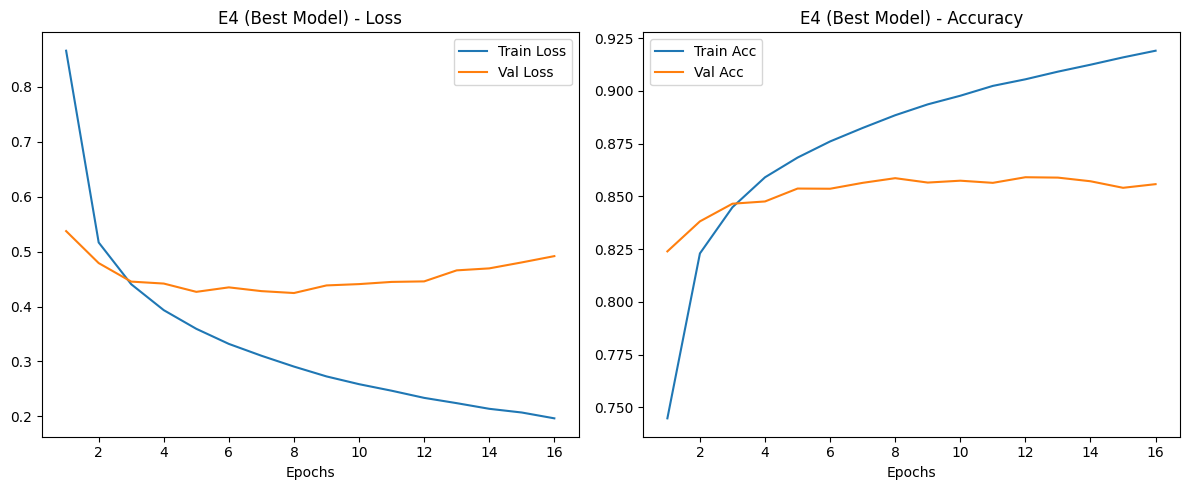

In [19]:
def plot_training_curves(history, title, save_path):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.plot(epochs, history['train_loss'], label='Train Loss')
    ax1.plot(epochs, history['val_loss'], label='Val Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epochs')
    ax1.legend()
    
    ax2.plot(epochs, history['train_acc'], label='Train Acc')
    ax2.plot(epochs, history['val_acc'], label='Val Acc')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

plot_training_curves(hist_e4, "E4 (Best Model)", os.path.join(FIGURES_DIR, "curves_best.png"))

In [20]:
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"\nИТОГОВАЯ ОЦЕНКА НА TEST (E4): Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")


ИТОГОВАЯ ОЦЕНКА НА TEST (E4): Loss: 0.5066, Accuracy: 0.8539


In [21]:
print("\n>>> Running O1 (LR extreme big: 1.0)...")
model_o1 = MLP(hidden_sizes=HIDDEN_SIZES, use_dropout=use_dropout_e4, use_batchnorm=use_bn_e4).to(device)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=1.0) 
hist_o1, best_acc_o1 = train_model(model_o1, train_loader, val_loader, criterion, optimizer_o1, device, epochs=5)


>>> Running O1 (LR extreme big: 1.0)...
Epoch 01/05 | Train Loss: 4.1553, Acc: 0.0214 | Val Loss: 3.9633, Acc: 0.0200
Epoch 02/05 | Train Loss: 4.0560, Acc: 0.0207 | Val Loss: 4.0112, Acc: 0.0223
Epoch 03/05 | Train Loss: 4.0502, Acc: 0.0206 | Val Loss: 4.1089, Acc: 0.0207
Epoch 04/05 | Train Loss: 4.0357, Acc: 0.0214 | Val Loss: 4.0366, Acc: 0.0219
Epoch 05/05 | Train Loss: 4.0386, Acc: 0.0214 | Val Loss: 4.1024, Acc: 0.0215


In [25]:
row_o1 = {
    'experiment_id': 'O1',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': f"Layers:{HIDDEN_SIZES} | Drop:{use_dropout_e4} | BN:{use_bn_e4}",
    'optimizer': 'Adam',
    'lr': 1.0,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': len(hist_o1['train_loss']),
    'best_val_accuracy': round(best_acc_o1, 4),
    'best_val_loss': round(min(hist_o1['val_loss']), 4)
}

if os.path.isfile(RUNS_PATH):
    df_existing = pd.read_csv(RUNS_PATH)
    df_existing = df_existing[df_existing['experiment_id'] != 'O1']
    df_new = pd.concat([df_existing, pd.DataFrame([row_o1])], ignore_index=True)
    df_new.to_csv(RUNS_PATH, index=False)
else:
    pd.DataFrame([row_o1]).to_csv(RUNS_PATH, index=False)

In [22]:
print("\n>>> Running O2 (LR too small: 1e-5)...")
model_o2 = MLP(hidden_sizes=HIDDEN_SIZES, use_dropout=use_dropout_e4, use_batchnorm=use_bn_e4).to(device)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)
hist_o2, best_acc_o2 = train_model(model_o2, train_loader, val_loader, criterion, optimizer_o2, device, epochs=7)
log_experiment('O2', {'hidden_sizes': HIDDEN_SIZES, 'use_dropout': use_dropout_e4, 'use_batchnorm': use_bn_e4}, hist_o2, best_acc_o2)


>>> Running O2 (LR too small: 1e-5)...
Epoch 01/07 | Train Loss: 3.1973, Acc: 0.3172 | Val Loss: 2.7062, Acc: 0.5121
Epoch 02/07 | Train Loss: 2.4672, Acc: 0.5612 | Val Loss: 2.1989, Acc: 0.6127
Epoch 03/07 | Train Loss: 2.0436, Acc: 0.6310 | Val Loss: 1.8341, Acc: 0.6620
Epoch 04/07 | Train Loss: 1.7270, Acc: 0.6712 | Val Loss: 1.5623, Acc: 0.6969
Epoch 05/07 | Train Loss: 1.4824, Acc: 0.7041 | Val Loss: 1.3528, Acc: 0.7221
Epoch 06/07 | Train Loss: 1.2907, Acc: 0.7294 | Val Loss: 1.1835, Acc: 0.7429
Epoch 07/07 | Train Loss: 1.1410, Acc: 0.7485 | Val Loss: 1.0545, Acc: 0.7579


In [23]:
print("\n>>> Running O3 (SGD + Momentum + Weight Decay)...")
model_o3 = MLP(hidden_sizes=HIDDEN_SIZES, use_dropout=use_dropout_e4, use_batchnorm=use_bn_e4).to(device)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4) 
hist_o3, best_acc_o3 = train_model(model_o3, train_loader, val_loader, criterion, optimizer_o3, device, epochs=12)

row_o3 = {
    'experiment_id': 'O3',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': f"Layers:{HIDDEN_SIZES} | Drop:{use_dropout_e4} | BN:{use_bn_e4}",
    'optimizer': 'SGD',
    'lr': 1e-2,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': len(hist_o3['train_loss']),
    'best_val_accuracy': round(best_acc_o3, 4),
    'best_val_loss': round(min(hist_o3['val_loss']), 4)
}

if os.path.isfile(RUNS_PATH):
    df_existing = pd.read_csv(RUNS_PATH)
    df_existing = df_existing[df_existing['experiment_id'] != 'O3']
    df_new = pd.concat([df_existing, pd.DataFrame([row_o3])], ignore_index=True)
    df_new.to_csv(RUNS_PATH, index=False)
else:
    pd.DataFrame([row_o3]).to_csv(RUNS_PATH, index=False)


>>> Running O3 (SGD + Momentum + Weight Decay)...
Epoch 01/12 | Train Loss: 0.9006, Acc: 0.7336 | Val Loss: 0.5530, Acc: 0.8192
Epoch 02/12 | Train Loss: 0.5253, Acc: 0.8238 | Val Loss: 0.4961, Acc: 0.8352
Epoch 03/12 | Train Loss: 0.4477, Acc: 0.8439 | Val Loss: 0.4569, Acc: 0.8451
Epoch 04/12 | Train Loss: 0.3985, Acc: 0.8574 | Val Loss: 0.4507, Acc: 0.8482
Epoch 05/12 | Train Loss: 0.3641, Acc: 0.8671 | Val Loss: 0.4396, Acc: 0.8528
Epoch 06/12 | Train Loss: 0.3387, Acc: 0.8749 | Val Loss: 0.4312, Acc: 0.8515
Epoch 07/12 | Train Loss: 0.3148, Acc: 0.8827 | Val Loss: 0.4476, Acc: 0.8496
Epoch 08/12 | Train Loss: 0.2970, Acc: 0.8875 | Val Loss: 0.4345, Acc: 0.8527
Epoch 09/12 | Train Loss: 0.2838, Acc: 0.8915 | Val Loss: 0.4351, Acc: 0.8556
Epoch 10/12 | Train Loss: 0.2667, Acc: 0.8974 | Val Loss: 0.4348, Acc: 0.8565
Epoch 11/12 | Train Loss: 0.2541, Acc: 0.9004 | Val Loss: 0.4436, Acc: 0.8542
Epoch 12/12 | Train Loss: 0.2456, Acc: 0.9031 | Val Loss: 0.4526, Acc: 0.8508


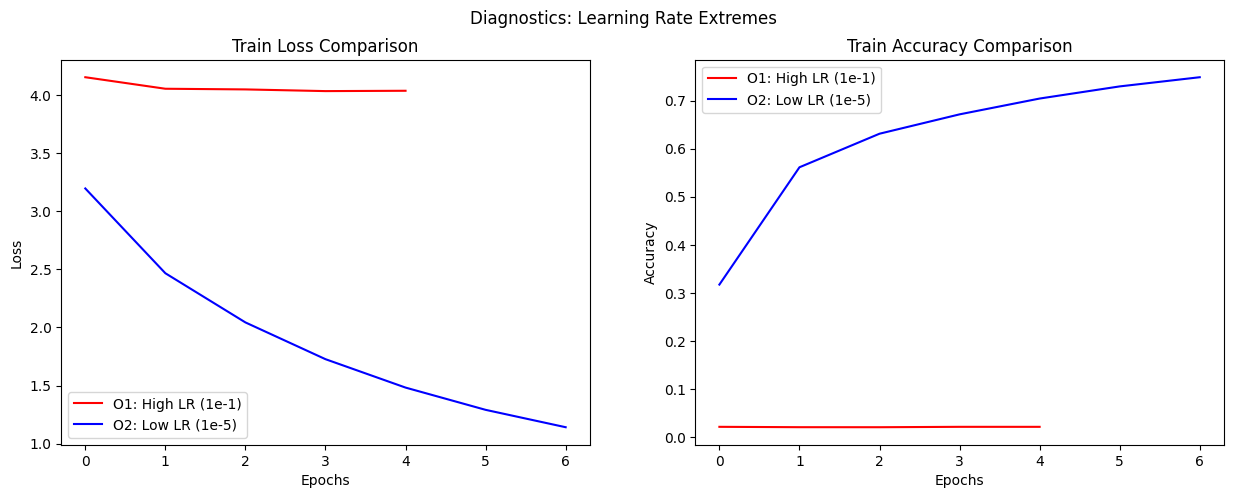

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(hist_o1['train_loss'], label='O1: High LR (1e-1)', color='red')
ax1.plot(hist_o2['train_loss'], label='O2: Low LR (1e-5)', color='blue')
ax1.set_title('Train Loss Comparison')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(hist_o1['train_acc'], label='O1: High LR (1e-1)', color='red')
ax2.plot(hist_o2['train_acc'], label='O2: Low LR (1e-5)', color='blue')
ax2.set_title('Train Accuracy Comparison')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.suptitle("Diagnostics: Learning Rate Extremes")
plt.savefig(os.path.join(FIGURES_DIR, "curves_lr_extremes.png"))
plt.show()